In [5]:
from pathlib import Path

def find_project_root(start: Path, markers=("pyproject.toml", ".git")):
    for p in [start] + list(start.parents):
        if any((p / m).exists() for m in markers):
            return p
    raise RuntimeError("Project root not found")

ROOT = find_project_root(Path.cwd())

print(ROOT)

/home/urdatorn/git/gh/aristophanis-cantica


# Melodic 

In [6]:
import numpy as np
from scipy import stats

def merged_regression_analysis(y):
    """
    Performs linear and quadratic regression on the input y-values.
    Keeps exact numeric types upstream and converts to float only at regression time.
    """
    y = np.array([float(v) if v is not None else np.nan for v in y], dtype=float)
    x = np.arange(len(y), dtype=float)

    mask = ~np.isnan(y)
    x = x[mask]
    y = y[mask]

    if x.size == 0:
        raise ValueError("No numeric values available for regression after filtering NaNs.")
    if x.size < 2:
        raise ValueError("At least two numeric points are required for linear regression.")

    # Linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    r2_linear = r_value ** 2

    # Quadratic regression (requires >= 3 points)
    if x.size >= 3:
        coeffs = np.polyfit(x, y, 2)
        y_pred_quad = np.polyval(coeffs, x)
        ss_res = np.sum((y - y_pred_quad) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2_quad = 1 - ss_res / ss_tot if ss_tot != 0 else 0
        eq_r_quad = np.sign(coeffs[0]) * np.sqrt(abs(r2_quad)) if r2_quad >= 0 else 0
    else:
        r2_quad = np.nan
        eq_r_quad = np.nan

    def interpret_r(r):
        abs_r = abs(r)
        if abs_r < 0.1:
            return "Trivial (Cohen)"
        elif abs_r < 0.3:
            return "Small (Cohen)"
        elif abs_r < 0.5:
            return "Medium (Cohen)"
        else:
            return "Large (Cohen)"

    print(f"\nRegression Analysis Summary:")
    print("Linear Regression:")
    print(f"  - Correlation coefficient (r): {r_value:.3f} ({interpret_r(r_value)})")
    print(f"  - R²: {r2_linear:.3f}")
    print(f"  - p-value: {p_value:.3f}")
    print("Quadratic Regression:")
    if np.isnan(r2_quad):
        print("  - Not enough points for quadratic regression")
    else:
        print(f"  - R²: {r2_quad:.3f}")
        print(f"  - Equivalent r: {eq_r_quad:.3f} ({interpret_r(eq_r_quad)})")

In [7]:
from collections import defaultdict
from fractions import Fraction
from numbers import Real

from responsio_accentuum import compatibility_corpus

def average_by_index_reversed(nested):
    # Flatten to all innermost numeric lists, accepting Fraction values.
    def collect_lists(x):
        if isinstance(x, list) and x and all(isinstance(i, Real) for i in x):
            return [x[::-1]]  # Reverse innermost list
        elif isinstance(x, list):
            result = []
            for item in x:
                result.extend(collect_lists(item))
            return result
        return []

    all_lists = collect_lists(nested)
    if not all_lists:
        raise ValueError(
            "No numeric innermost lists found. If values are Fraction objects, "
            "ensure collector checks use numbers.Real."
        )

    # Keep exact arithmetic in Fraction space as long as possible.
    sums = defaultdict(lambda: Fraction(0, 1))
    counts = defaultdict(int)

    for lst in all_lists:
        for i, val in enumerate(lst):
            sums[i] += val
            counts[i] += 1

    max_index = max(sums.keys(), default=-1)
    averages = []

    for i in range(max_index + 1):
        if counts[i] > 0:
            #if counts[i] < 8:
            #    print(f"Index {i}: has less than 8 terms (value: {sums[i]})")
            averages.append(sums[i] / counts[i])  # still Fraction if inputs are Fraction
        else:
            averages.append(None)

    return averages

observed_scores = compatibility_corpus(ROOT / 'data/compiled/')
expected_scores = compatibility_corpus(ROOT / 'data/compiled/baselines/baseline_aristophanes')


print("Observed:")
average_by_position_reversed_observed = average_by_index_reversed(observed_scores)
merged_regression_analysis(average_by_position_reversed_observed[:15])

print("\nExpected:")
average_by_position_reversed_expected = average_by_index_reversed(expected_scores)
merged_regression_analysis(average_by_position_reversed_expected[:15])

12it [00:00, 67.86it/s]                       
7it [00:00, 184.22it/s]              

Observed:

Regression Analysis Summary:
Linear Regression:
  - Correlation coefficient (r): -0.261 (Small (Cohen))
  - R²: 0.068
  - p-value: 0.348
Quadratic Regression:
  - R²: 0.155
  - Equivalent r: 0.393 (Medium (Cohen))

Expected:

Regression Analysis Summary:
Linear Regression:
  - Correlation coefficient (r): -0.119 (Small (Cohen))
  - R²: 0.014
  - p-value: 0.672
Quadratic Regression:
  - R²: 0.027
  - Equivalent r: 0.166 (Small (Cohen))


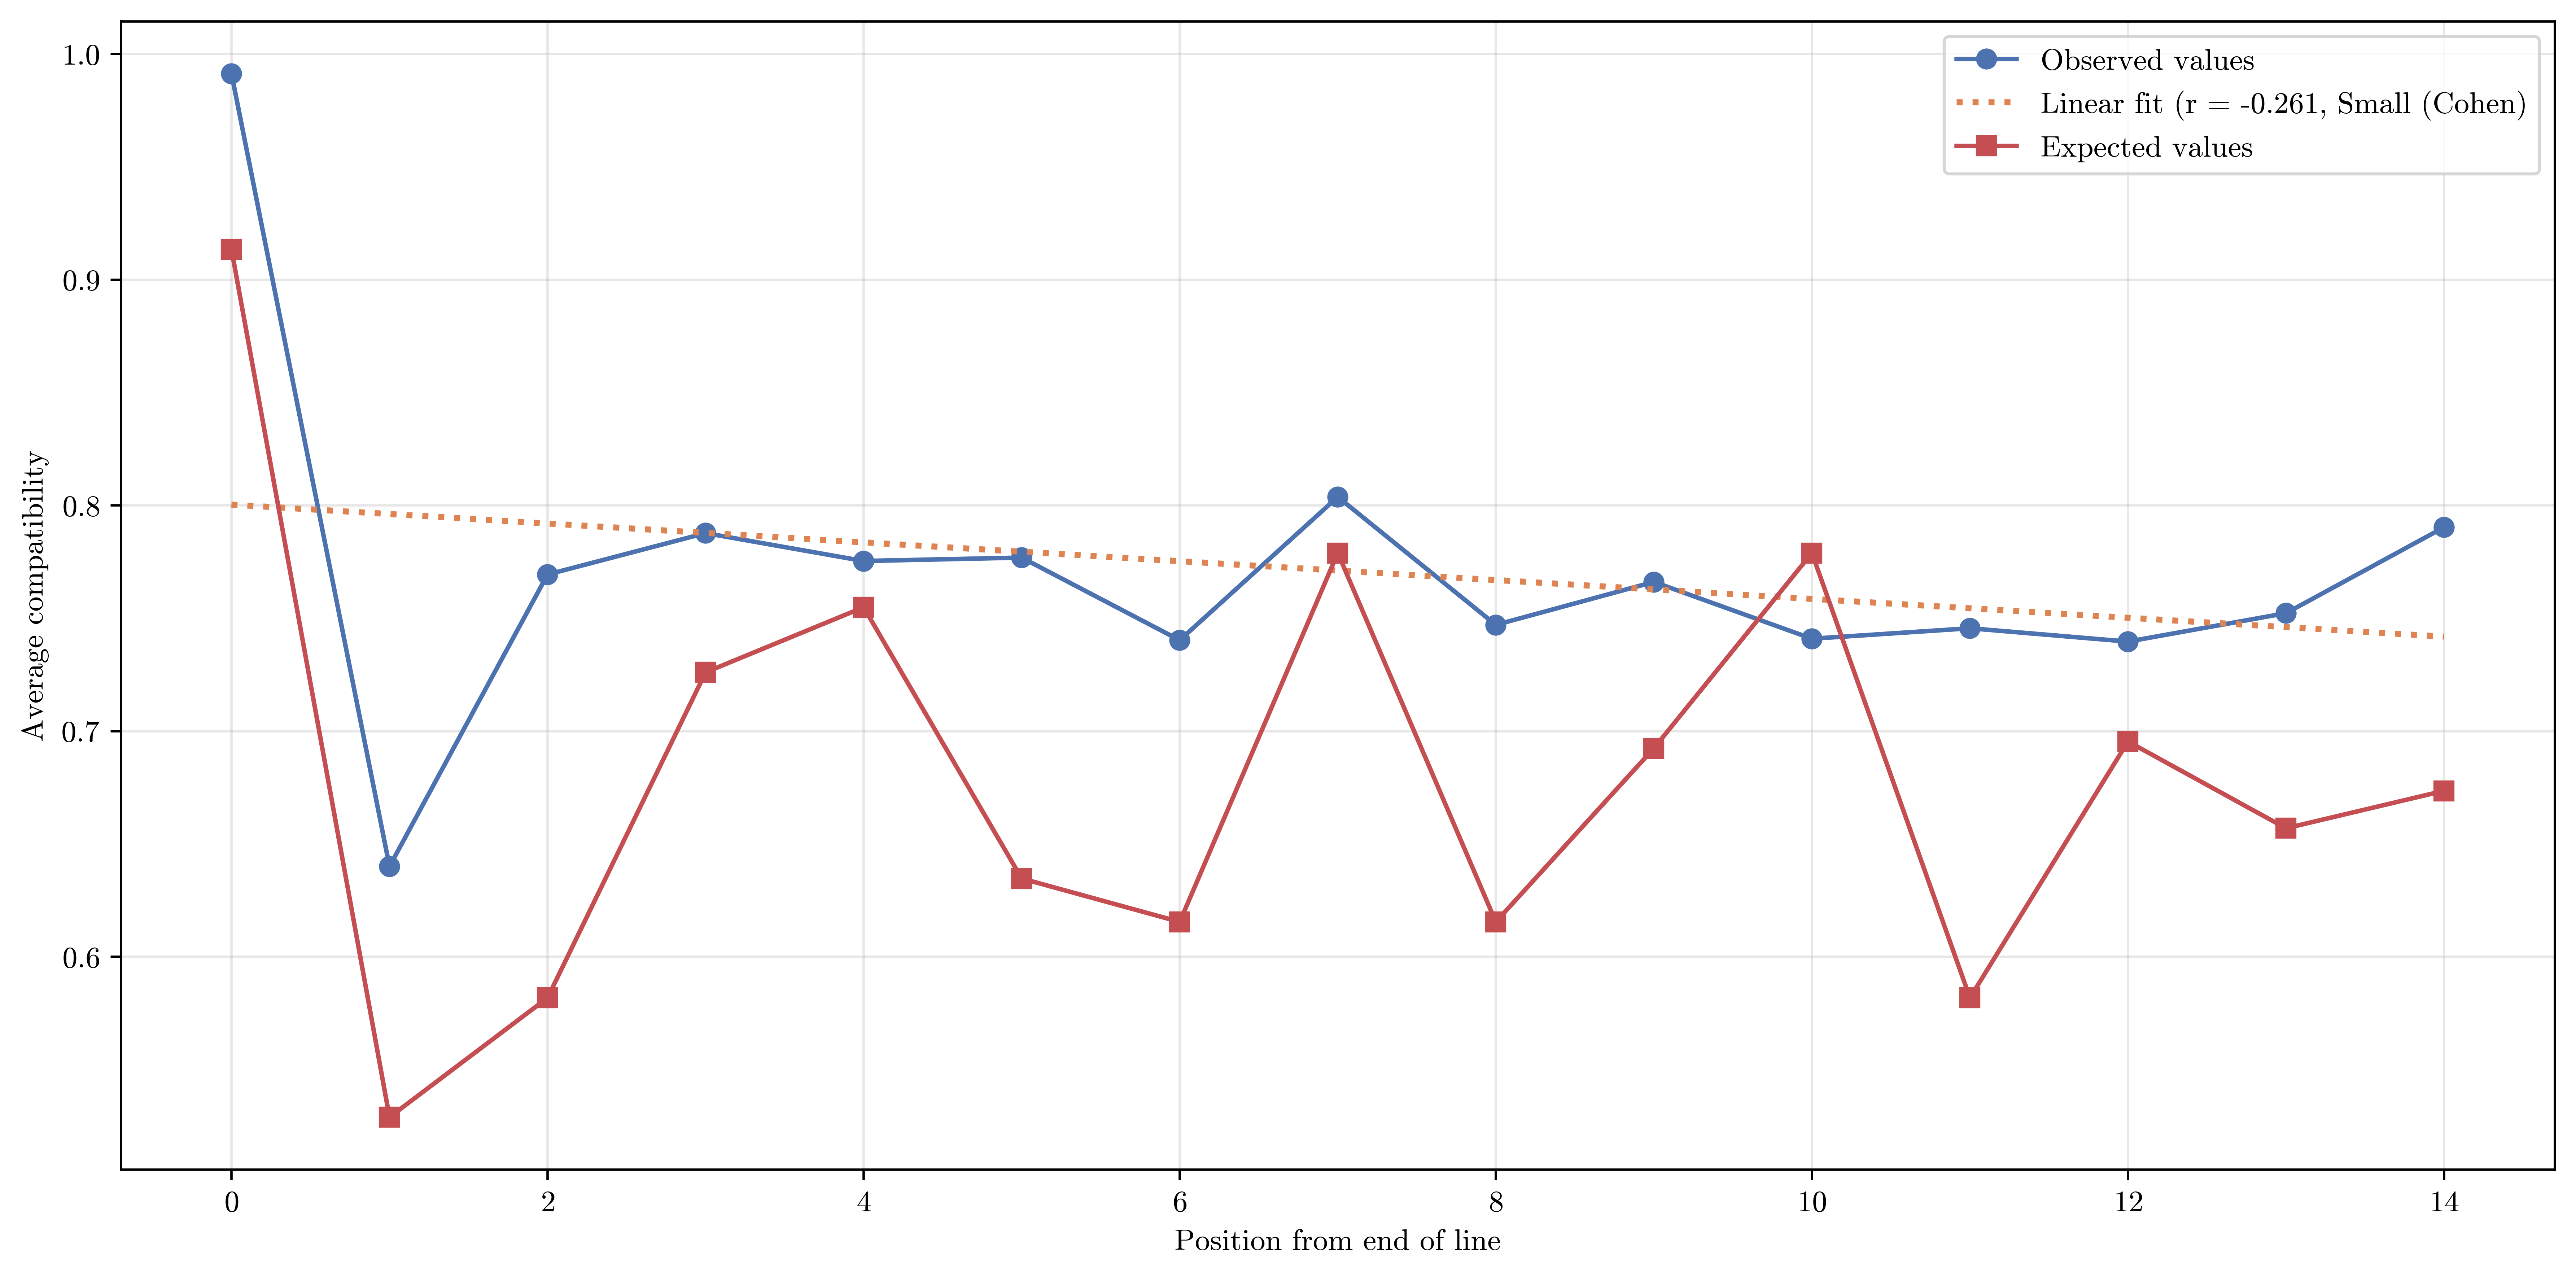

In [9]:
import os
import matplotlib.pyplot as plt
from src.plot import apply_plotting_poetry_palette

apply_plotting_poetry_palette()
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

def cohen_r_label(r):
    abs_r = abs(r)
    if abs_r < 0.1:
        return 'Trivial (Cohen)'
    elif abs_r < 0.3:
        return 'Small (Cohen)'
    elif abs_r < 0.5:
        return 'Medium (Cohen)'
    else:
        return 'Large (Cohen)'

# Observed
y_observed = np.array(average_by_position_reversed_observed[:15], dtype=float)
x_observed = np.arange(len(y_observed))
mask = ~np.isnan(y_observed)
x_observed = x_observed[mask]
y_observed = y_observed[mask]

slope, intercept, r_value, p_value, std_err = stats.linregress(x_observed, y_observed)
linear_fit = slope * x_observed + intercept

quad_coeffs = np.polyfit(x_observed, y_observed, 2)
quadratic_fit = np.polyval(quad_coeffs, x_observed)

# Expected
y_expected = np.array(average_by_position_reversed_expected[:15], dtype=float)
x_expected = np.arange(len(y_expected))
mask_expected = ~np.isnan(y_expected)
x_expected = x_expected[mask_expected]
y_expected = y_expected[mask_expected]

plt.figure(figsize=(12, 6))
plt.plot(x_observed, y_observed, marker='o', color=default_colors[0], label='Observed values')
plt.plot(
    x_observed,
    linear_fit,
    color=default_colors[1],
    linewidth=2,
    linestyle=':',
    label=f'Linear fit (r = {r_value:.3f}, {cohen_r_label(r_value)}'
 )
#plt.plot(x_observed, quadratic_fit, color=default_colors[2], linewidth=2, label=f'Quadratic fit (R^2 = {1 - np.sum((y_observed - quadratic_fit) ** 2) / np.sum((y_observed - np.mean(y_observed)) ** 2):.3f})')

plt.plot(x_expected, y_expected, marker='s', color=default_colors[3], label='Expected values')

plt.plot
plt.xlabel('Position from end of line')
plt.ylabel('Average compatibility')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
os.makedirs(ROOT / 'media' / 'line_ends', exist_ok=True)

plt.savefig(ROOT / 'media' / 'line_ends' / 'comp_line_end.png', dpi=600)
plt.show()
